# 05 — Results & Visualisation

The key finding: **does lagged sentiment predict abnormal returns?**

Also produces the final figures for LinkedIn/TikTok.

**Prerequisite:** Run notebooks 01–04 first.

In [1]:
import sys
sys.path.insert(0, '../src')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr, spearmanr

from utils import TICKERS, EVENT_DATES

car_df  = pd.read_csv('../data/processed/car_results.csv', parse_dates=['date'])
scores  = pd.read_csv('../data/processed/sentiment_scores.csv', parse_dates=['date'])
scores['date'] = pd.to_datetime(scores['date'])
car_df['date'] = pd.to_datetime(car_df['date'])

/Users/jamilasabazova/opt/anaconda3/lib/python3.9/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.8.3' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/Users/jamilasabazova/opt/anaconda3/lib/python3.9/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


## 5a. Merge sentiment + abnormal returns

For the key test we align daily sentiment with daily abnormal returns and test whether lag-1 and lag-2 sentiment predicts next-day AR.

In [2]:
# Merge AR with sentiment on date × event
merged = car_df.merge(
    scores[['date', 'event', 'vader_weighted', 'finbert_weighted']],
    on=['date', 'event'],
    how='left'
)
merged = merged.sort_values(['ticker', 'event', 'day'])
print(merged.head(10))

     ticker         event  event_date       date  day        ar       car  \
48  1913.HK  full_trailer  2026-02-01 2026-01-29   -2 -0.002384 -0.002384   
49  1913.HK  full_trailer  2026-02-01 2026-01-30   -1  0.010263  0.007879   
50  1913.HK  full_trailer  2026-02-01 2026-02-02    0  0.013260  0.021139   
51  1913.HK  full_trailer  2026-02-01 2026-02-03    1 -0.011159  0.009980   
52  1913.HK  full_trailer  2026-02-01 2026-02-04    2  0.012130  0.022110   
53  1913.HK  full_trailer  2026-02-01 2026-02-05    3  0.024727  0.046837   
54  1913.HK  full_trailer  2026-02-01 2026-02-06    4  0.000760  0.047598   
55  1913.HK  full_trailer  2026-02-01 2026-02-09    5  0.007365  0.054962   
96  1913.HK  nyc_premiere  2026-04-20 2026-04-16   -2  0.006524  0.006524   
97  1913.HK  nyc_premiere  2026-04-20 2026-04-17   -1 -0.003820  0.002704   

        beta     alpha  vader_weighted  finbert_weighted  
48  0.638562 -0.001841        0.981900               NaN  
49  0.638562 -0.001841            

## 5b. Lag correlation — sentiment → abnormal return

Test lags 0, 1, 2 for both VADER and FinBERT vs AR.

In [3]:
results = []

for ticker in TICKERS:
    for model in ['vader_weighted', 'finbert_weighted']:
        for lag in [0, 1, 2]:
            sub = merged[merged['ticker'] == ticker].copy()

            # Create lagged sentiment within each event
            sub['lagged_sentiment'] = sub.groupby('event')[model].shift(lag)
            aligned = sub[['ar', 'lagged_sentiment']].dropna()

            if len(aligned) < 5:
                continue

            r_p, p_p = pearsonr(aligned['lagged_sentiment'], aligned['ar'])
            r_s, p_s = spearmanr(aligned['lagged_sentiment'], aligned['ar'])

            results.append({
                'ticker': ticker,
                'model':  model.replace('_weighted','').upper(),
                'lag':    lag,
                'pearson_r': r_p,
                'pearson_p': p_p,
                'spearman_r': r_s,
                'spearman_p': p_s,
                'n': len(aligned),
            })

lag_df = pd.DataFrame(results)
print(lag_df.sort_values('pearson_r', ascending=False).head(20).to_string(index=False))

 ticker model  lag  pearson_r  pearson_p  spearman_r  spearman_p  n
  MC.PA VADER    0   0.603439   0.006229    0.492982    0.031982 19
     EL VADER    2   0.419136   0.119921    0.450000    0.092357 15
1913.HK VADER    1   0.281006   0.258660    0.250774    0.315513 18
 KER.PA VADER    2   0.173016   0.554187    0.274725    0.341830 14
   CPRI VADER    0   0.129215   0.587170   -0.046617    0.845270 20
    TPR VADER    0   0.105788   0.657125   -0.108271    0.649567 20
    TPR VADER    1   0.095606   0.697026    0.052632    0.830556 19
   CPRI VADER    1   0.093135   0.704515   -0.203509    0.403352 19
 KER.PA VADER    0   0.071138   0.772275    0.171930    0.481548 19
   CPRI VADER    2   0.026184   0.926200   -0.032143    0.909462 15
  MC.PA VADER    1  -0.045623   0.857341   -0.128999    0.609950 18
1913.HK VADER    0  -0.081591   0.739847   -0.075439    0.758887 19
1913.HK VADER    2  -0.085349   0.771739   -0.129670    0.658619 14
     EL VADER    1  -0.115737   0.637050    0.12

## 5c. Lag correlation heatmap

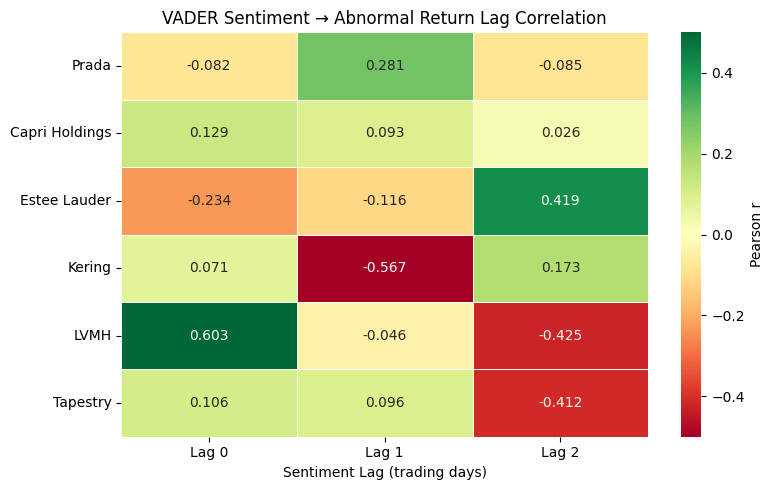

/Users/jamilasabazova/opt/anaconda3/lib/python3.9/site-packages/seaborn/matrix.py:309: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  ax.set(xlim=(0, self.data.shape[1]), ylim=(0, self.data.shape[0]))
/Users/jamilasabazova/opt/anaconda3/lib/python3.9/site-packages/seaborn/matrix.py:309: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  ax.set(xlim=(0, self.data.shape[1]), ylim=(0, self.data.shape[0]))


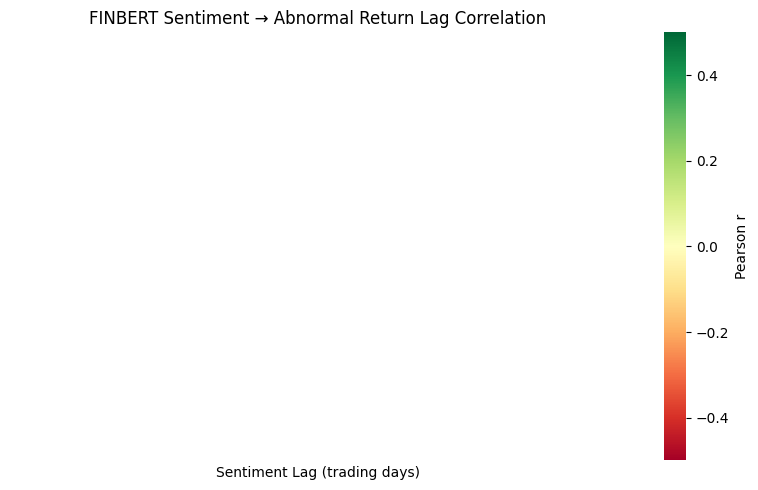

In [4]:
for model in ['VADER', 'FINBERT']:
    sub = lag_df[lag_df['model'] == model]
    pivot = sub.pivot(index='ticker', columns='lag', values='pearson_r')
    pivot.index = [TICKERS.get(t, t) for t in pivot.index]
    pivot.columns = [f'Lag {l}' for l in pivot.columns]

    fig, ax = plt.subplots(figsize=(8, 5))
    sns.heatmap(pivot, annot=True, fmt='.3f', cmap='RdYlGn', center=0,
                linewidths=0.5, ax=ax, vmin=-0.5, vmax=0.5,
                cbar_kws={'label': 'Pearson r'})
    ax.set_title(f'{model} Sentiment → Abnormal Return Lag Correlation')
    ax.set_xlabel('Sentiment Lag (trading days)')
    plt.tight_layout()
    plt.savefig(f'../results/figures/lag_correlation_{model.lower()}.png', dpi=150, bbox_inches='tight')
    plt.show()

lag_df.to_csv('../results/tables/lag_correlation.csv', index=False)

## 5d. Key finding summary

Narrative output for the LinkedIn article and TikTok results video.

In [5]:
car_summary = pd.read_csv('../data/processed/car_summary.csv')
car_summary['ticker_name'] = car_summary['ticker'].map(TICKERS)

sig = car_summary[car_summary['p_value'] < 0.05]
best = car_summary.loc[car_summary['total_car'].abs().idxmax()]
best_lag = lag_df.loc[lag_df['pearson_r'].abs().idxmax()]

print('═' * 60)
print('KEY FINDINGS')
print('═' * 60)

if len(sig) > 0:
    print(f'\n{len(sig)} statistically significant CAR results (p < 0.05):')
    for _, row in sig.iterrows():
        print(f'  {row["ticker_name"]} | {row["event"]} | CAR={row["total_car"]*100:.2f}% | p={row["p_value"]:.3f}')
else:
    print('\nNo statistically significant CARs (null hypothesis not rejected)')
    print('→ Cultural sentiment does not produce measurable equity price effects in these windows')

print(f'\nLargest absolute CAR: {best["ticker_name"]} at {best["event"]} = {best["total_car"]*100:.2f}%')
print(f'\nStrongest sentiment-return correlation:')
print(f'  {best_lag["ticker"]} | {best_lag["model"]} lag={best_lag["lag"]} | Pearson r={best_lag["pearson_r"]:.3f} p={best_lag["pearson_p"]:.3f}')
print('═' * 60)

════════════════════════════════════════════════════════════
KEY FINDINGS
════════════════════════════════════════════════════════════

No statistically significant CARs (null hypothesis not rejected)
→ Cultural sentiment does not produce measurable equity price effects in these windows

Largest absolute CAR: Tapestry at full_trailer = 17.98%

Strongest sentiment-return correlation:
  MC.PA | VADER lag=0 | Pearson r=0.603 p=0.006
════════════════════════════════════════════════════════════


## 5e. Portfolio figure for LinkedIn / TikTok

Single clean chart: CPRI vs TPR CAR paths across the four events. 
This is the most compelling visual comparison (Versace cameo vs no association).

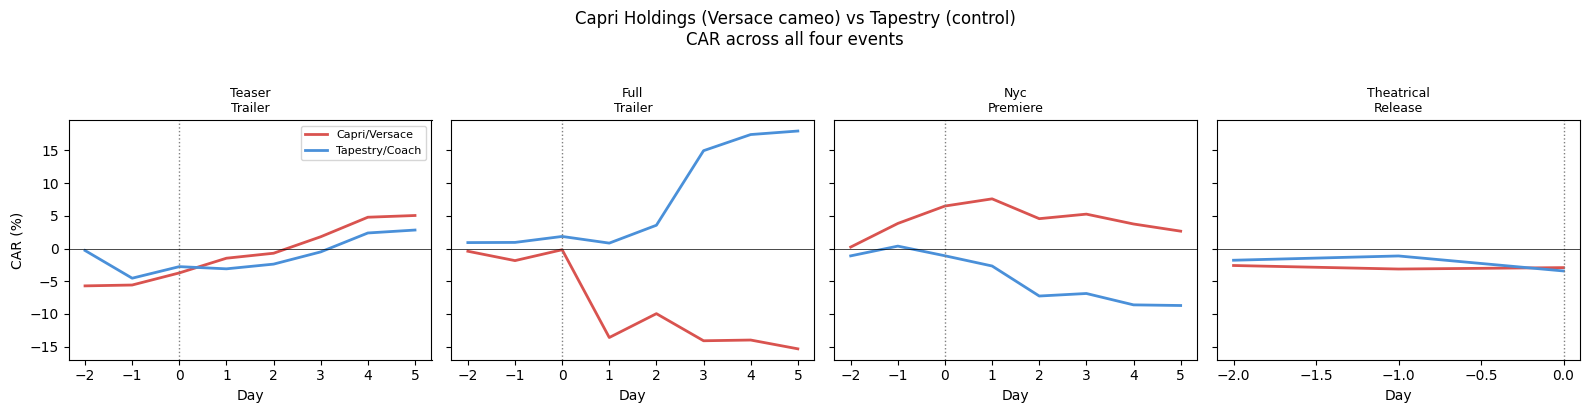

In [6]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4), sharey=True)

for ax, event in zip(axes, EVENT_DATES):
    for ticker, color, label in [('CPRI','#D9534F','Capri/Versace'), ('TPR','#4A90D9','Tapestry/Coach')]:
        t_df = car_df[(car_df['ticker']==ticker) & (car_df['event']==event)].sort_values('day')
        if not t_df.empty:
            ax.plot(t_df['day'], t_df['car']*100, label=label, color=color, linewidth=2)
    ax.axvline(0, color='gray', linestyle=':', linewidth=1)
    ax.axhline(0, color='black', linewidth=0.5)
    ax.set_title(event.replace('_','\n').title(), fontsize=9)
    ax.set_xlabel('Day')

axes[0].set_ylabel('CAR (%)')
axes[0].legend(fontsize=8)
plt.suptitle('Capri Holdings (Versace cameo) vs Tapestry (control)\nCAR across all four events', y=1.02)
plt.tight_layout()
plt.savefig('../results/figures/cpri_vs_tpr.png', dpi=150, bbox_inches='tight')
plt.show()